# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


Dataset ImageFolder
    Number of datapoints: 4720
    Root location: ./my_data/dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Dataset ImageFolder
    Number of datapoints: 1088
    Root location: ./my_data/dataset/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Number of samples: 4720
Number of features: torch.Size([3, 224, 224])
Example data:


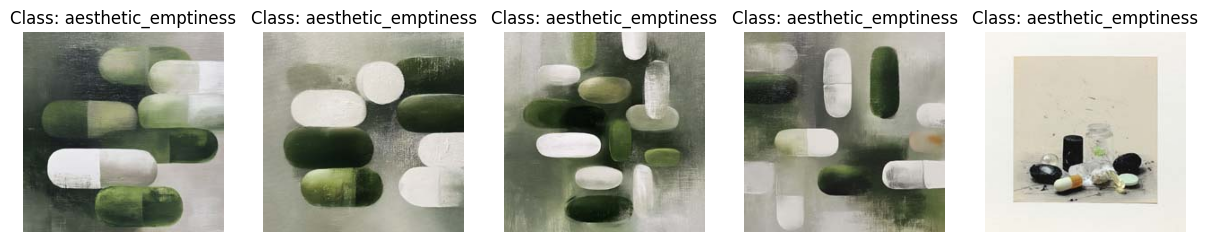

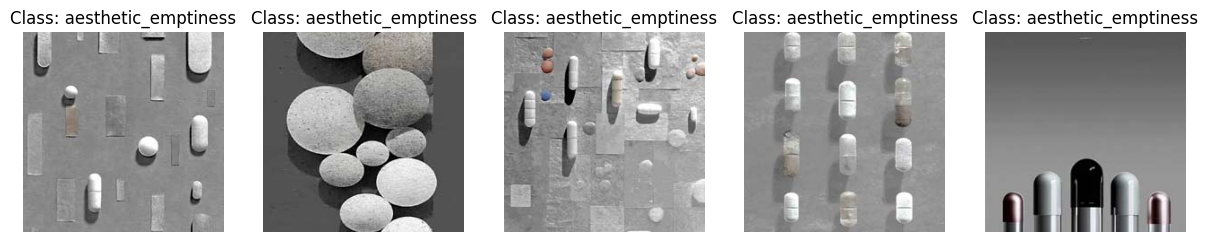

In [20]:
import pandas as pd
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from google.colab import drive

import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, num_images=5):
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        # Получаем картинку и индекс класса
        image, label = dataset[i]

        # Переводим тензор обратно в формат для отрисовки (H, W, C)
        # Изначально в PyTorch: (C, H, W)
        image = image.numpy().transpose((1, 2, 0))

        # Денормализация, если вы добавляли Normalize в transform (здесь не нужно)
        image = np.clip(image, 0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"Class: {dataset.classes[label]}")
        plt.axis('off')
    plt.show()

#!pip install --upgrade gdown


# https://learn.deeplearning.ai/specializations/pytorch-for-deep-learning-professional-certificate/lesson/bvvjkv/introduction-to-data-pipelines
# video with images


# Скачиваем файл по ID
#file_id = '1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c'
#url = f'https://google.com{file_id}'
#url = "https://drive.google.com/file/d/1GbwrOMykQa0YJ7EXFXZxFUVIj2OFjl2c/view?usp=drive_link"
#!gdown {url}

# Распаковываем архив (название файла из ссылки обычно dataset.zip)
# Замените 'dataset.zip', если файл называется иначе после скачивания
#!unzip -q dataset.zip -d ./my_data

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
#df = pd.read_csv('your_dataset.csv')
#df = pd.DataFrame(columns=['col1', 'col2', 'col3'])

#mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)


# 2. Указываем путь к КОРНЕВОЙ папке датасета
# Важно: ImageFolder ожидает, что внутри указанного пути лежат папки с классами.
# Если 'aesthetic_emptiness' — это один из классов, указывайте путь до папки 'test'

transform = transforms.Compose([
    transforms.Resize((224, 224)), # Укажите нужный вам размер
    transforms.ToTensor(),
])

data_path = './my_data/dataset'



my_dataset_train = torchvision.datasets.ImageFolder(root=f"{data_path}/train" , transform=transform)
my_dataset_test = torchvision.datasets.ImageFolder(root=f"{data_path}/test",  transform=transform)


print(my_dataset_train)
print(my_dataset_test)




# Number of samples
num_samples = len(my_dataset_train)

# Number of features
num_features = my_dataset_train[0][0].shape

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
#print(df.head())
# Вызываем функцию
show_images(my_dataset_train)
show_images(my_dataset_test)



## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


In [ ]:
# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


In [ ]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


In [ ]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

# Your code to investigate possible biases goes here


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [ ]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
